# CardioRisk Prediction — Classifying Cardiovascular Disease Risk

**Author:** Sabyasachi Sarkar &nbsp;

## Objective
This project builds and compares machine learning classifiers to predict whether a patient is at risk of cardiovascular disease, based on demographic, physiological, and lifestyle attributes (age, blood pressure, cholesterol, glucose, smoking, alcohol use, physical activity, and BMI). The goal is to identify a model that balances predictive accuracy with interpretability for clinical screening use cases.

## Data Source
A health survey dataset of ~70,000 patient records with physiological measurements and a binary cardiovascular disease label, cleaned down to ~68,645 valid records after removing physiologically implausible entries.

## Tools Used
`pandas` · `numpy` · `matplotlib` · `seaborn` · `scikit-learn`

## What's Covered
1. Data understanding and initial inspection
2. Data cleaning — physiological validity checks, unit conversions (age, height), data type fixes
3. Exploratory data analysis — univariate, bivariate, and correlation analysis
4. Train-test split (70:30, stratified)
5. Feature engineering — BMI creation, category consolidation, dummy encoding, scaling
6. Model building — Linear SVM, Decision Tree, hyperparameter-tuned Decision Tree and RBF SVM
7. Final model evaluation, selection, and model cards for each candidate

> A full written report with detailed narrative and figures is available as a PDF in this repo.

> **Note:** This notebook was built in Google Colab with data stored in Google Drive (`health_data.csv`). Update this path to match your own environment before running.

---

# **Section 1: Data Understanding**

In [ ]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1.1.1 Load Dataset**

In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/health_data.csv')

**1.1.2 Check the first few entries**

In [ ]:
# Check the first few entries
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


**1.1.3 Remove irrelevant columns**

In [ ]:
# Remove irrelevant columns like unique identifiers or index
df = df.drop(columns=['Unnamed: 0', 'id'])
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


**1.1.4 Inspect the shape**

In [ ]:
# Inspect the shape of the dataset
df.shape

(70000, 12)

**1.1.5 Inspect columns + summary**

In [ ]:
# Inspect the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


# **Section 2: Data Cleaning**

**2.1.1 Statistical summary**

In [ ]:
# Check the summary of the dataset
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


**2.1.2 Handle invalid/illogical values**

In [ ]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc

# 1. Blood pressure: keep only physiologically plausible values (30-300 as per assignment hint)
df = df[(df['ap_hi'] >= 30) & (df['ap_hi'] <= 300)]
df = df[(df['ap_lo'] >= 30) & (df['ap_lo'] <= 300)]

# 2. Logical check: systolic (ap_hi) must be greater than diastolic (ap_lo)
df = df[df['ap_hi'] > df['ap_lo']]

# 3. Height: remove implausible adult heights (using a reasonable clinical range, e.g. 100-220 cm)
df = df[(df['height'] >= 100) & (df['height'] <= 220)]

# 4. Weight: remove implausible adult weights (e.g. 30-200 kg)
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

df.reset_index(drop=True, inplace=True)
df.shape

(68645, 12)

**2.1.3 Convert age (days→years) and height (cm→m)**

In [ ]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context

# Convert age from days to years
df['age'] = (df['age'] / 365.25).round(1)

# Convert height from cm to meters (useful for BMI calculation later)
df['height_m'] = df['height'] / 100

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,height_m
0,50.4,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0,1.68
1,55.4,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1,1.56
2,51.6,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1,1.65
3,48.2,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1,1.69
4,47.8,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0,1.56


**2.2.1 Fix data types**

In [ ]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
df[categorical_cols] = df[categorical_cols].astype('category')

In [ ]:
# Check the final data types post conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68645 entries, 0 to 68644
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          68645 non-null  float64 
 1   gender       68645 non-null  category
 2   height       68645 non-null  float64 
 3   weight       68645 non-null  float64 
 4   ap_hi        68645 non-null  float64 
 5   ap_lo        68645 non-null  float64 
 6   cholesterol  68645 non-null  category
 7   gluc         68645 non-null  category
 8   smoke        68645 non-null  category
 9   alco         68645 non-null  category
 10  active       68645 non-null  category
 11  cardio       68645 non-null  category
 12  height_m     68645 non-null  float64 
dtypes: category(7), float64(6)
memory usage: 3.6 MB


# **Section 3: EDA**

**3.1.1 Visualise numerical features**

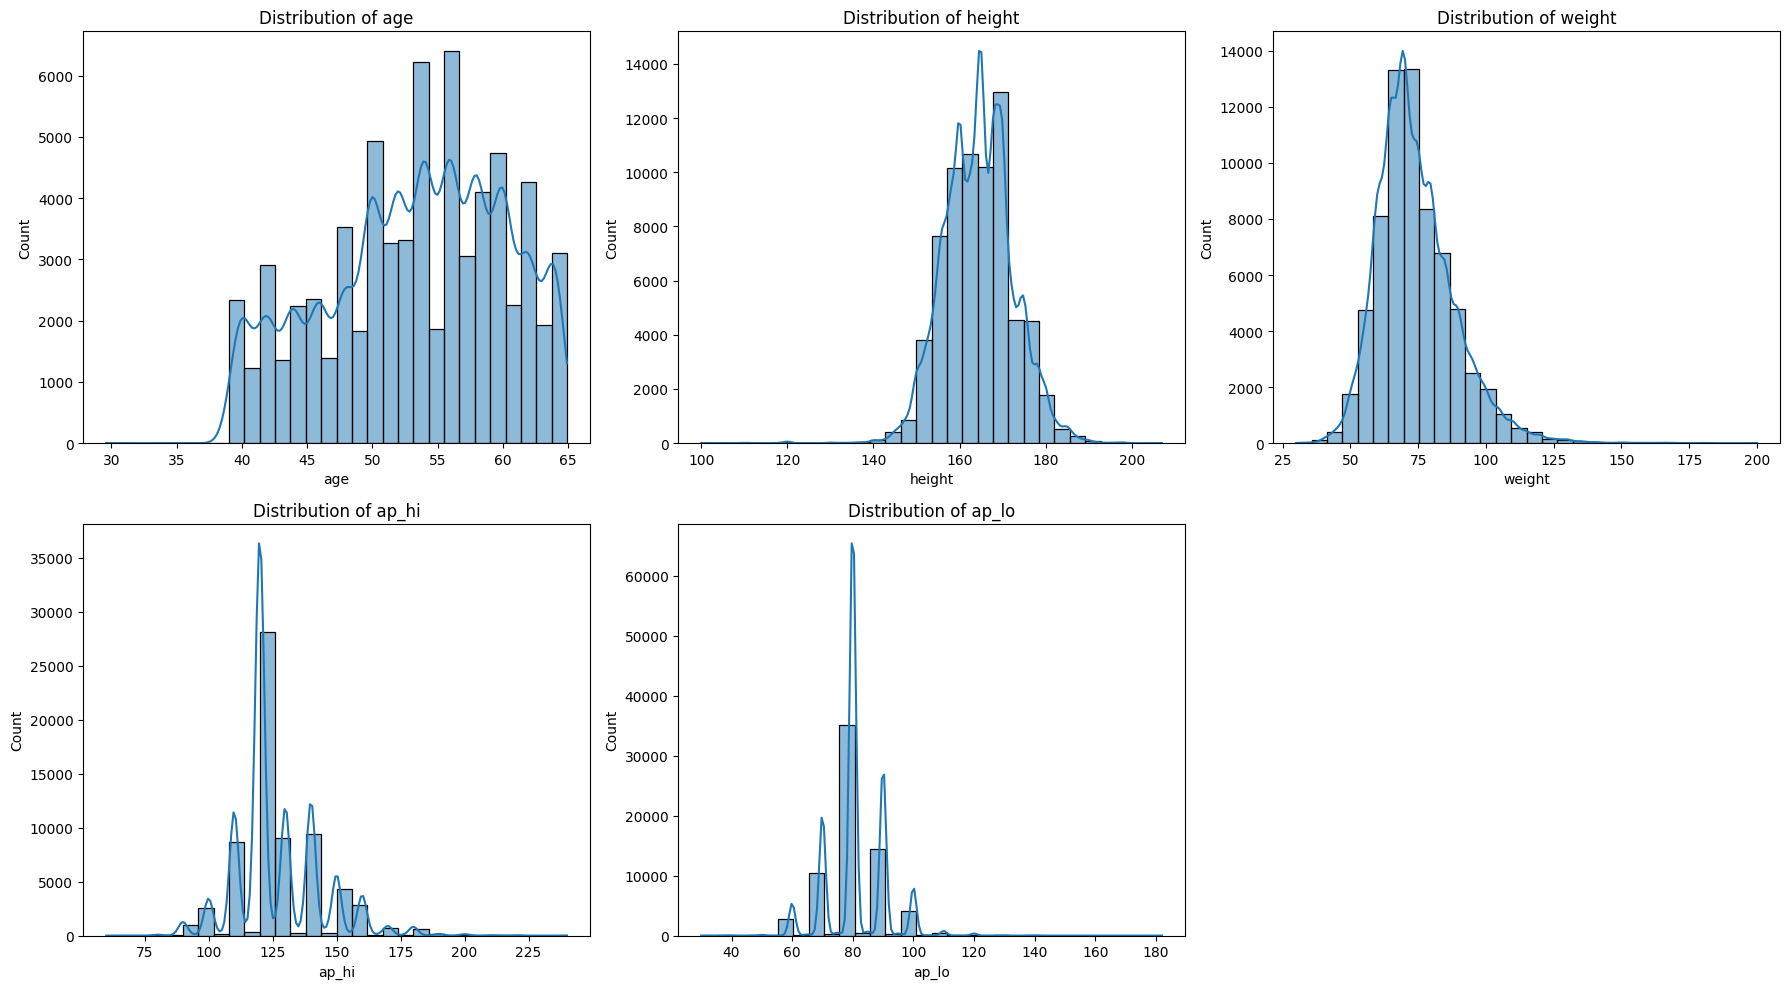

In [ ]:
# Plot all the numerical columns to understand their distribution
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')

# hide the unused 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

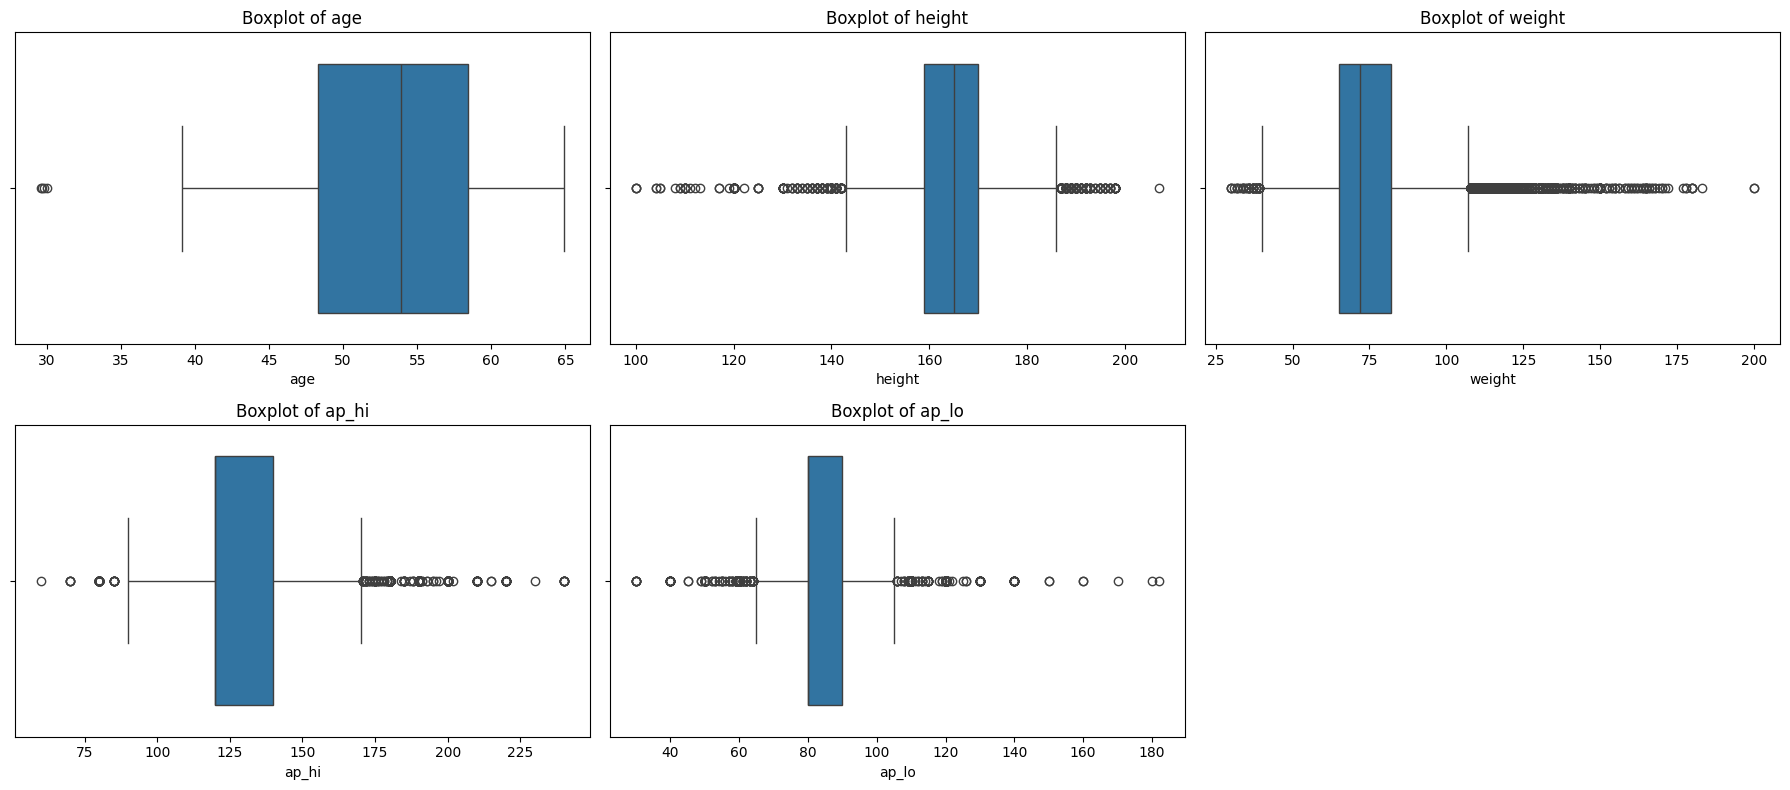

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

**3.1.2 Visualise categorical features**

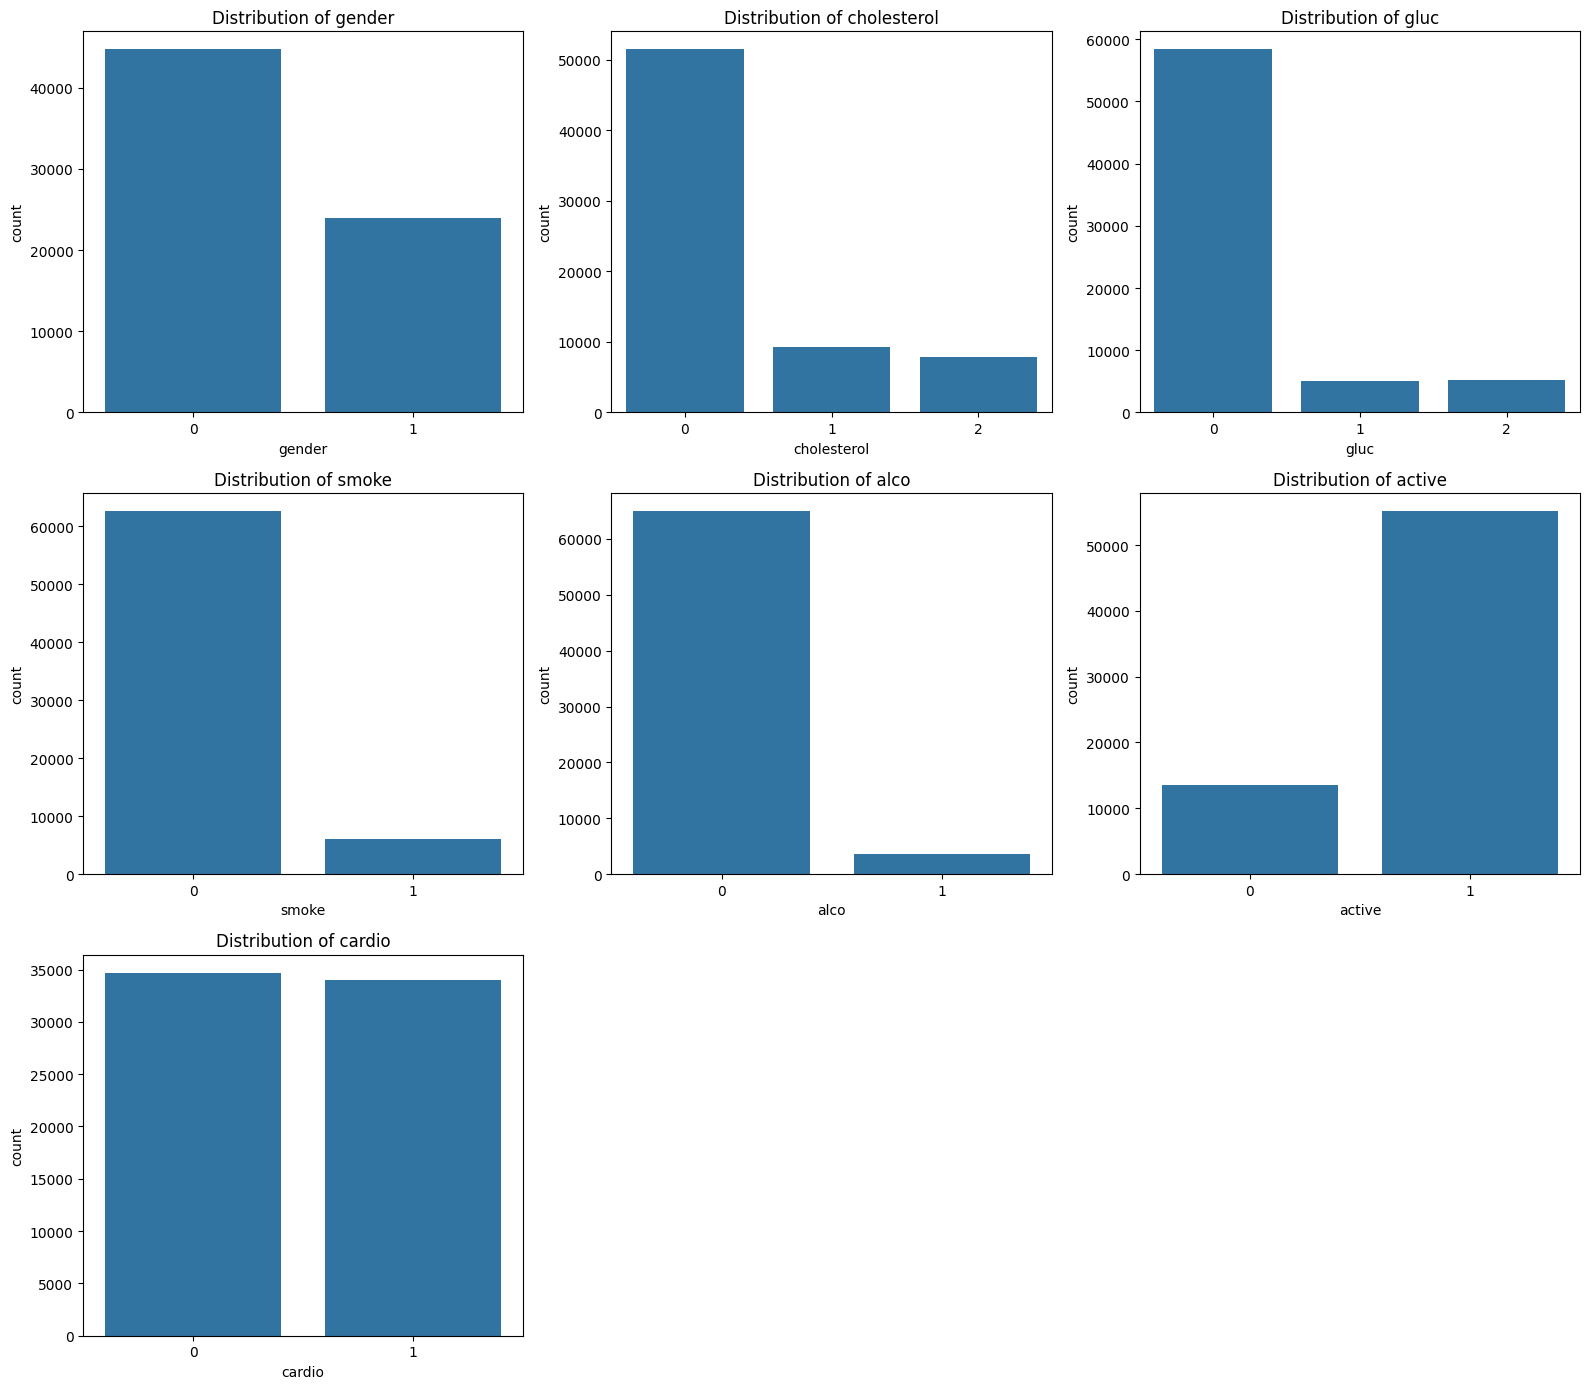

In [ ]:
# Select and plot categorical columns
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**3.1.3 Class distribution of target**

In [ ]:
# Class distribution of positive and negative classes
df['cardio'].value_counts(normalize=True) * 100

,proportion
cardio,
0,50.526622
1,49.473378


**3.2.1 Correlation analysis**

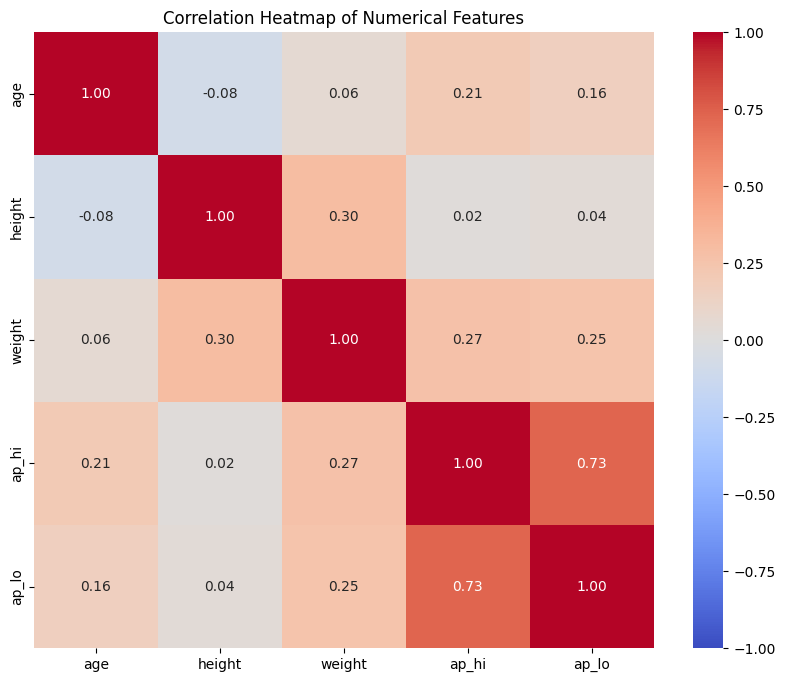

In [ ]:
# Plot Heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**3.3.1 Bivariate: categorical features vs target**


Cardio rate by gender:
gender
0    0.492105
1    0.499645
Name: cardio, dtype: float64

Cardio rate by cholesterol:
cholesterol
0    0.435457
1    0.596280
2    0.762552
Name: cardio, dtype: float64

Cardio rate by gluc:
gluc
0    0.475601
1    0.588711
2    0.617523
Name: cardio, dtype: float64

Cardio rate by smoke:
smoke
0    0.497269
1    0.468445
Name: cardio, dtype: float64

Cardio rate by alco:
alco
0    0.495760
1    0.476516
Name: cardio, dtype: float64

Cardio rate by active:
active
0    0.532746
1    0.485430
Name: cardio, dtype: float64


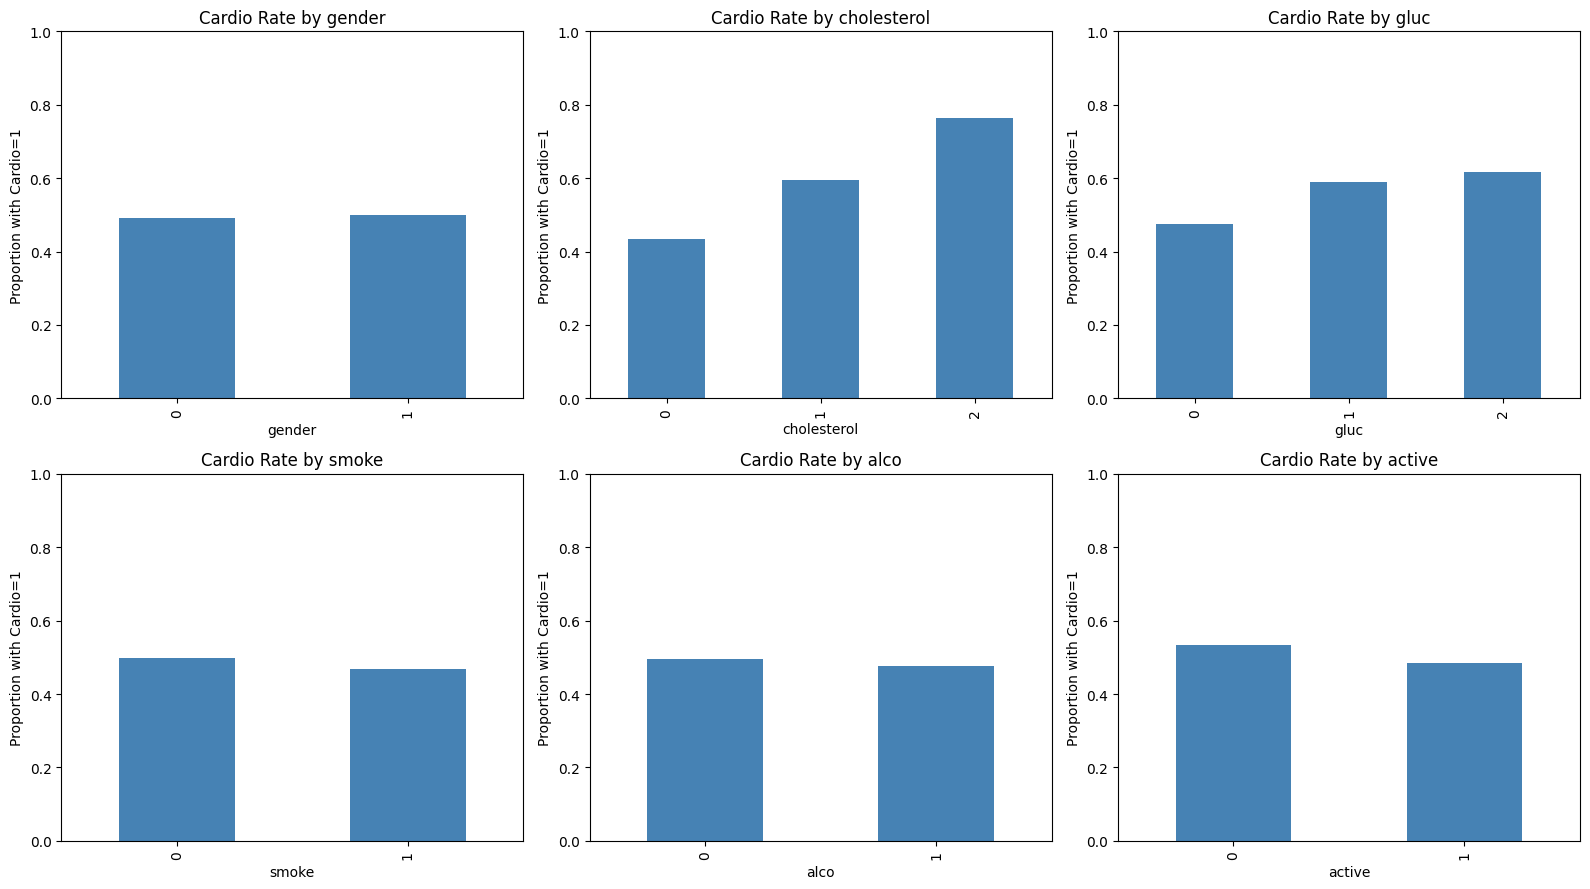

In [ ]:
# Write a function to analyse the target variable likelihood for categorical features
def cardio_rate_by_category(df, col):
    """Returns the proportion of cardio=1 for each category of the given column."""
    rate = df.groupby(col)['cardio'].apply(lambda x: (x == 1).mean())
    return rate

categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    rate = cardio_rate_by_category(df, col)
    print(f"\nCardio rate by {col}:\n{rate}")
    rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Cardio Rate by {col}')
    axes[i].set_ylabel('Proportion with Cardio=1')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**3.3.2 Numerical features vs target**

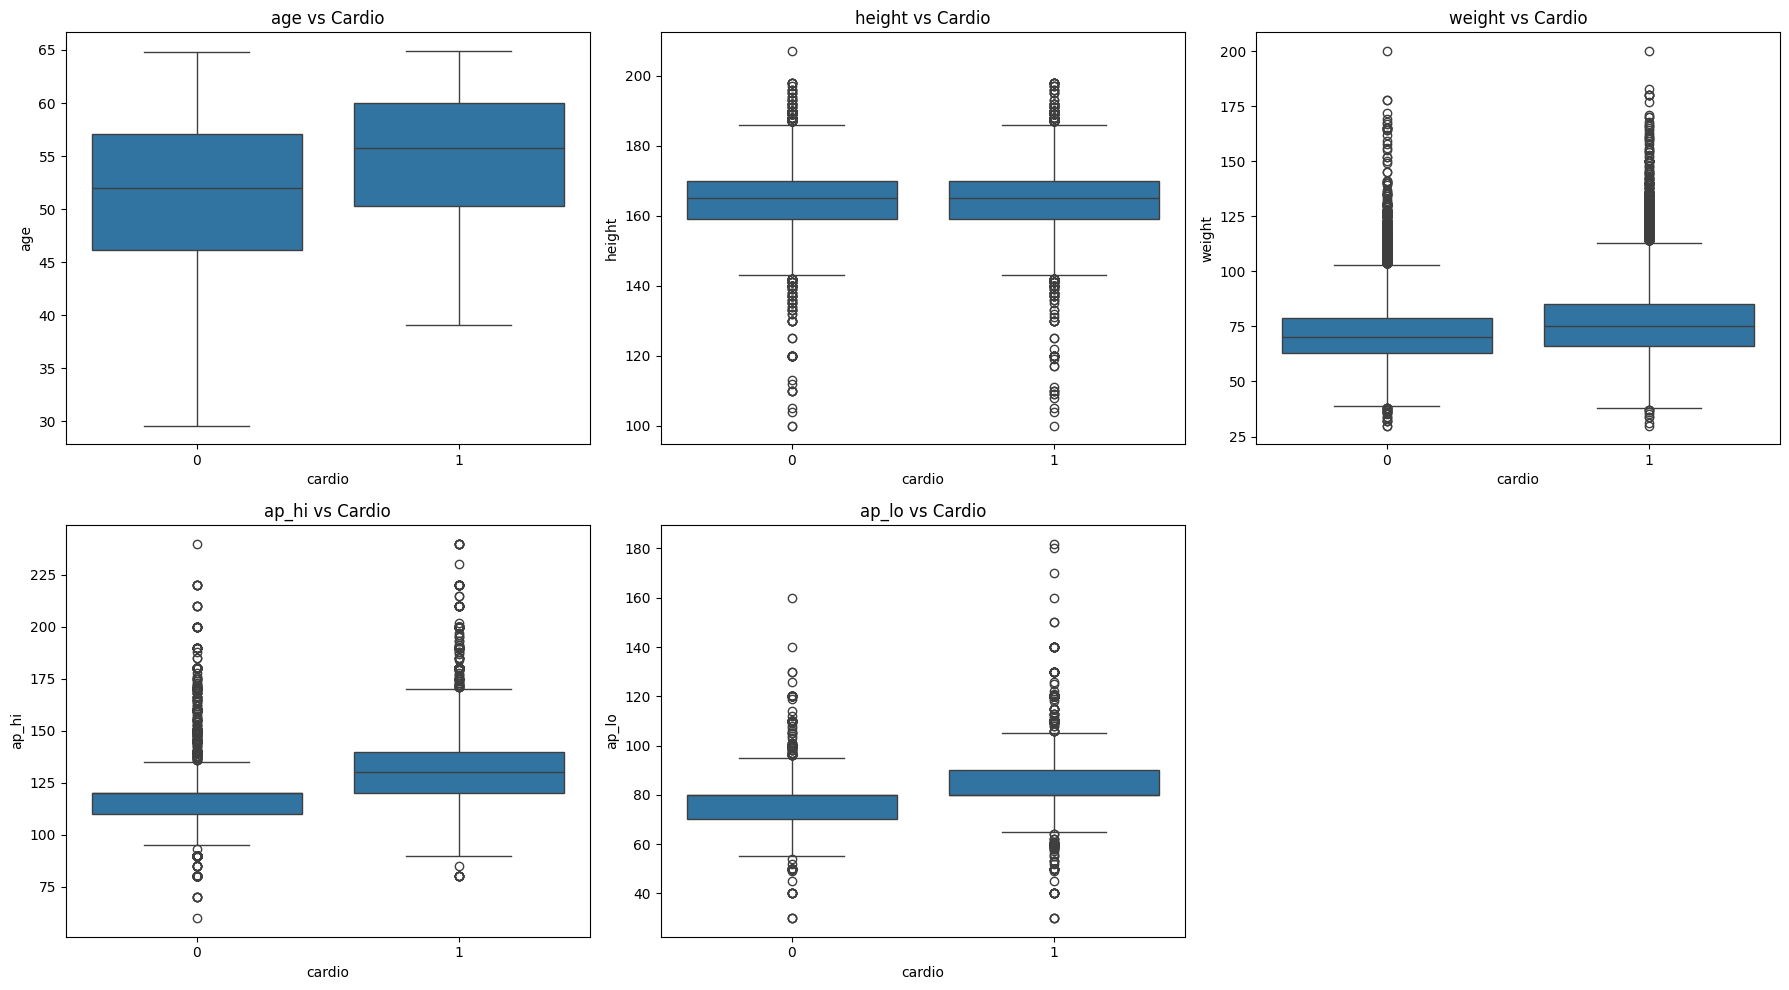

In [ ]:
# Plot distribution for each numerical column with target variable
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='cardio', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Cardio')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# **Section 4: Train-Test Split**

**4.1.1 Define X and y**

In [ ]:
# Put all the feature variables in X and target in y
X = df.drop(columns=['cardio'])
y = df['cardio']

**4.1.2 Split 70:30 + reset index**

In [ ]:
#  Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# Reset index for all train and test sets
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [ ]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(48051, 12) (20594, 12) (48051,) (20594,)


# **Section 5: Feature Engineering**

**5.1.1 Create BMI**

In [ ]:
# Create a new feature 'BMI'
X_train['BMI'] = X_train['weight'] / (X_train['height_m'] ** 2)
X_test['BMI'] = X_test['weight'] / (X_test['height_m'] ** 2)

X_train[['weight', 'height_m', 'BMI']].head()

,weight,height_m,BMI
0,60.0,1.57,24.341758
1,90.0,1.76,29.054752
2,60.0,1.65,22.038567
3,83.0,1.66,30.120482
4,68.0,1.59,26.897670


**5.1.2 Correlation check for BMI**

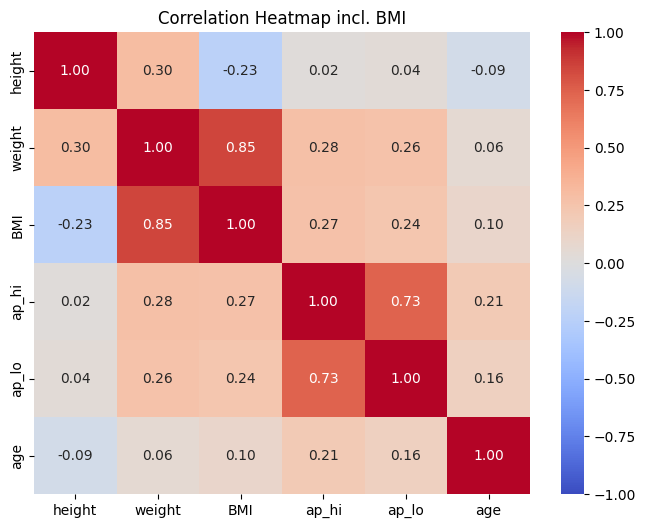

In [ ]:
# Plot check correlation
plt.figure(figsize=(8, 6))
check_cols = ['height', 'weight', 'BMI', 'ap_hi', 'ap_lo', 'age']
sns.heatmap(X_train[check_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap incl. BMI')
plt.show()

In [ ]:
# Did you find any highly correlated features? What steps should you take
# BMI and weight show a very high correlation (0.85), which is expected since BMI is
# mathematically derived from weight (and height). Keeping both would introduce redundant,
# highly collinear information into the model. Since BMI is a more clinically meaningful
# composite metric (used in real medical practice) than raw weight or height individually,
# we drop 'weight' and 'height' and retain BMI as the representative feature.

X_train = X_train.drop(columns=['weight', 'height', 'height_m'])
X_test = X_test.drop(columns=['weight', 'height', 'height_m'])

X_train.columns

Index(['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'BMI'],
      dtype='object')

**5.2.1 Combine low-frequency categories**

In [ ]:
print(X_train['cholesterol'].value_counts())
print()
print(X_train['gluc'].value_counts())

cholesterol
0    36030
1     6513
2     5508
Name: count, dtype: int64

gluc
0    40883
2     3630
1     3538
Name: count, dtype: int64


In [ ]:
# Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol

# Combine categories 1 (above normal) and 2 (well above normal) into a single "abnormal" category
# for both cholesterol and gluc, since both are individually low-frequency minority classes
# relative to category 0, and the assignment specifically calls these two out.

X_train['cholesterol'] = X_train['cholesterol'].replace({1: 1, 2: 1})
X_test['cholesterol'] = X_test['cholesterol'].replace({1: 1, 2: 1})

X_train['gluc'] = X_train['gluc'].replace({1: 1, 2: 1})
X_test['gluc'] = X_test['gluc'].replace({1: 1, 2: 1})

print(X_train['cholesterol'].value_counts())
print()
print(X_train['gluc'].value_counts())

cholesterol
0    36030
1    12021
Name: count, dtype: int64

gluc
0    40883
1     7168
Name: count, dtype: int64


**5.3.1 Create dummy variables**

In [ ]:
# Identify the columns for creating dummy variables
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X_train[categorical_cols].nunique()

,0
gender,2
cholesterol,2
gluc,2
smoke,2
alco,2
active,2


In [ ]:
# Create dummy variables for independent columns on training data
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_train.head()

,age,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,61.5,120.0,80.0,24.341758,False,False,False,False,False,True
1,42.1,120.0,90.0,29.054752,True,True,False,False,False,True
2,43.6,120.0,80.0,22.038567,False,False,False,False,False,True
3,47.4,110.0,70.0,30.120482,False,False,False,False,False,True
4,47.6,120.0,80.0,26.897670,False,False,False,False,False,True


In [ ]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_test.head()

,age,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,45.6,180.0,100.0,31.141869,False,True,True,False,False,True
1,59.5,130.0,80.0,33.563520,False,True,True,False,False,False
2,57.4,120.0,80.0,36.960829,False,False,False,False,False,True
3,60.0,130.0,80.0,25.727555,True,True,False,False,True,False
4,58.0,120.0,80.0,27.990363,False,True,True,False,False,True


In [ ]:
# Convert dummy boolean columns to integers for compatibility with sklearn models
dummy_cols = ['gender_1', 'cholesterol_1', 'gluc_1', 'smoke_1', 'alco_1', 'active_1']
X_train[dummy_cols] = X_train[dummy_cols].astype(int)
X_test[dummy_cols] = X_test[dummy_cols].astype(int)

**5.4.1 Feature scaling**

In [ ]:
# Scale the numeric features present in the training data
numerical_cols = ['age', 'ap_hi', 'ap_lo', 'BMI']

scaler = MinMaxScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Scale the numerical features present in the test data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train[numerical_cols].describe()

,age,ap_hi,ap_lo,BMI
count,48051.000000,48051.000000,48051.000000,48051.000000
mean,0.670790,0.370083,0.337470,0.118126
std,0.191989,0.092688,0.062382,0.037904
min,0.000000,0.000000,0.000000,0.000000
25%,0.528409,0.333333,0.328947,0.092709
50%,0.687500,0.333333,0.328947,0.110135
75%,0.815341,0.444444,0.394737,0.136737
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
print(X_train.shape, X_test.shape)
print(set(X_train.columns) - set(X_test.columns))
print(set(X_test.columns) - set(X_train.columns))

(48051, 10) (20594, 10)
set()
set()


# **Section 6: Model Building**

# 6.1 Linear SVM:

**6.1.1 Define and fit Linear SVM**

In [ ]:
# Define and fit linear SVM
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=42)

**6.1.2 Get predictions two ways: predict() vs predict_proba()**

In [ ]:
# Make predictions using predict()
y_train_pred_class = svm_linear.predict(X_train)

# Make predictions using predict_proba()
y_train_pred_proba = svm_linear.predict_proba(X_train)[:, 1]

# Convert probabilities to class labels using default 0.5 cutoff
y_train_pred_from_proba = (y_train_pred_proba >= 0.5).astype(int)

# Compare: how many predictions differ between the two methods?
mismatch = (y_train_pred_class != y_train_pred_from_proba).sum()
print(f"Number of mismatched predictions: {mismatch}")
print(f"Percentage mismatched: {mismatch / len(y_train) * 100:.2f}%")

Number of mismatched predictions: 1309
Percentage mismatched: 2.72%


**6.1.3 Find the optimal cutoff**

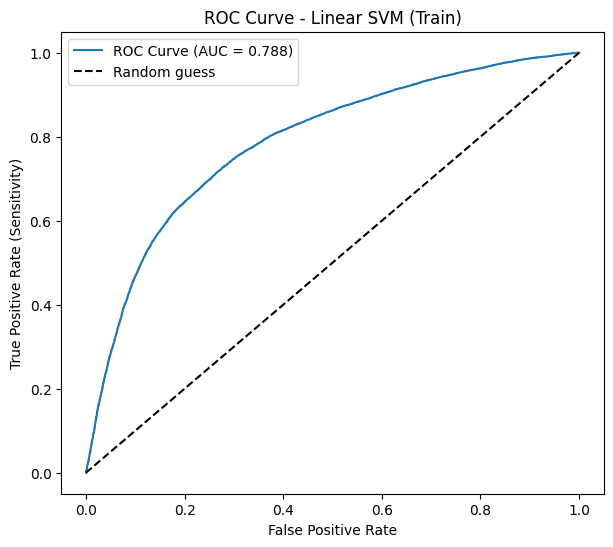

AUC Score: 0.7879


In [ ]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_proba)
auc_score = roc_auc_score(y_train, y_train_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Linear SVM (Train)')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

**6.1.4 Compare performance**

In [ ]:
# check the performance for the two methods (predict vs predict_proba @ 0.5)
print("Using predict():")
print(classification_report(y_train, y_train_pred_class))
print("\nUsing predict_proba() with 0.5 cutoff:")
print(classification_report(y_train, y_train_pred_from_proba))

Using predict():
              precision    recall  f1-score   support

           0       0.69      0.81      0.75     24279
           1       0.76      0.64      0.69     23772

    accuracy                           0.72     48051
   macro avg       0.73      0.72      0.72     48051
weighted avg       0.73      0.72      0.72     48051


Using predict_proba() with 0.5 cutoff:
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     24279
           1       0.75      0.66      0.70     23772

    accuracy                           0.72     48051
   macro avg       0.73      0.72      0.72     48051
weighted avg       0.73      0.72      0.72     48051



**6.1.5 Sensitivity/specificity/accuracy tradeoff plot**

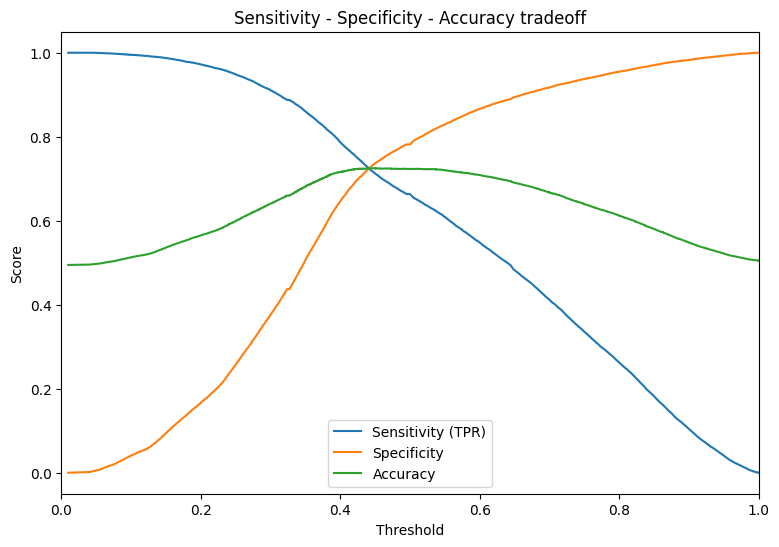

In [ ]:
# Find optimal cutoff by plotting sensitivity, specificity, accuracy across thresholds
cutoff_df = pd.DataFrame({'threshold': thresholds, 'tpr': tpr, 'fpr': fpr})
cutoff_df['specificity'] = 1 - cutoff_df['fpr']

# accuracy at each threshold
accuracies = []
for t in thresholds:
    preds = (y_train_pred_proba >= t).astype(int)
    accuracies.append(accuracy_score(y_train, preds))
cutoff_df['accuracy'] = accuracies

plt.figure(figsize=(9, 6))
plt.plot(cutoff_df['threshold'], cutoff_df['tpr'], label='Sensitivity (TPR)')
plt.plot(cutoff_df['threshold'], cutoff_df['specificity'], label='Specificity')
plt.plot(cutoff_df['threshold'], cutoff_df['accuracy'], label='Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Sensitivity - Specificity - Accuracy tradeoff')
plt.legend()
plt.xlim(0, 1)
plt.show()

**6.1.6 The optimal cutoff calculation + train evaluation**

In [ ]:
# Find the exact optimal cutoff (where sensitivity and specificity are closest)
cutoff_df['diff'] = abs(cutoff_df['tpr'] - cutoff_df['specificity'])
optimal_cutoff = cutoff_df.loc[cutoff_df['diff'].idxmin(), 'threshold']
print(f"Optimal cutoff: {optimal_cutoff:.4f}")

Optimal cutoff: 0.4412


In [ ]:
# Re-predict using the optimal cutoff instead of default 0.5
y_train_pred_optimal = (y_train_pred_proba >= optimal_cutoff).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred_optimal))
print()
print("Classification Report:")
print(classification_report(y_train, y_train_pred_optimal))

Confusion Matrix:
[[17589  6690]
 [ 6550 17222]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73     24279
           1       0.72      0.72      0.72     23772

    accuracy                           0.72     48051
   macro avg       0.72      0.72      0.72     48051
weighted avg       0.72      0.72      0.72     48051



**6.1.7 Final predictions with optimal cutoff, on BOTH train and test**

In [ ]:
# Make final prediction based on the optimal cutoff — on test set too
y_test_pred_proba = svm_linear.predict_proba(X_test)[:, 1]
y_test_pred_optimal = (y_test_pred_proba >= optimal_cutoff).astype(int)

print("Train performance:")
print(classification_report(y_train, y_train_pred_optimal))
print("\nTest performance:")
print(classification_report(y_test, y_test_pred_optimal))

Train performance:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73     24279
           1       0.72      0.72      0.72     23772

    accuracy                           0.72     48051
   macro avg       0.72      0.72      0.72     48051
weighted avg       0.72      0.72      0.72     48051


Test performance:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73     10405
           1       0.72      0.73      0.72     10189

    accuracy                           0.73     20594
   macro avg       0.73      0.73      0.73     20594
weighted avg       0.73      0.73      0.73     20594



**6.1.8  Precision-Recall curve**

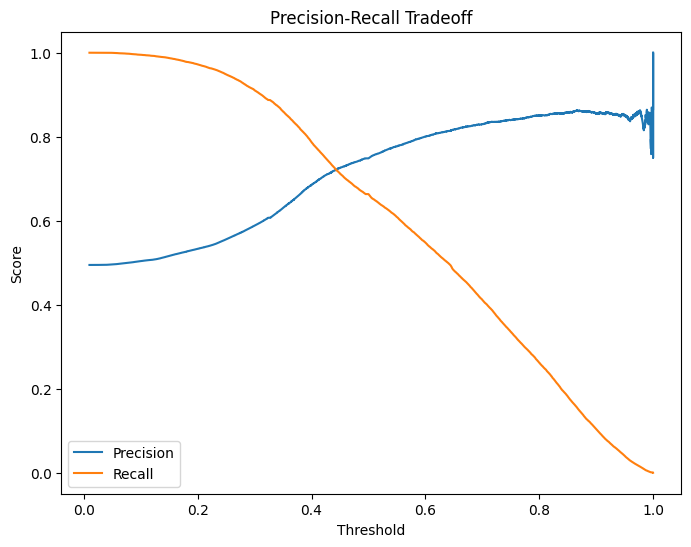

In [ ]:
# Compute precision-recall values and plot for various thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_train, y_train_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(pr_thresholds, precision[:-1], label='Precision')
plt.plot(pr_thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.show()

# 6.2 Decision Tree Classifier

**6.2.1 Define & fit**

In [ ]:
# Define and fit
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**6.2.2 Feature importance scores**

BMI              0.358518
age              0.255823
ap_hi            0.232399
ap_lo            0.047531
gender_1         0.031228
active_1         0.019462
cholesterol_1    0.016944
gluc_1           0.015339
smoke_1          0.013289
alco_1           0.009467
dtype: float64


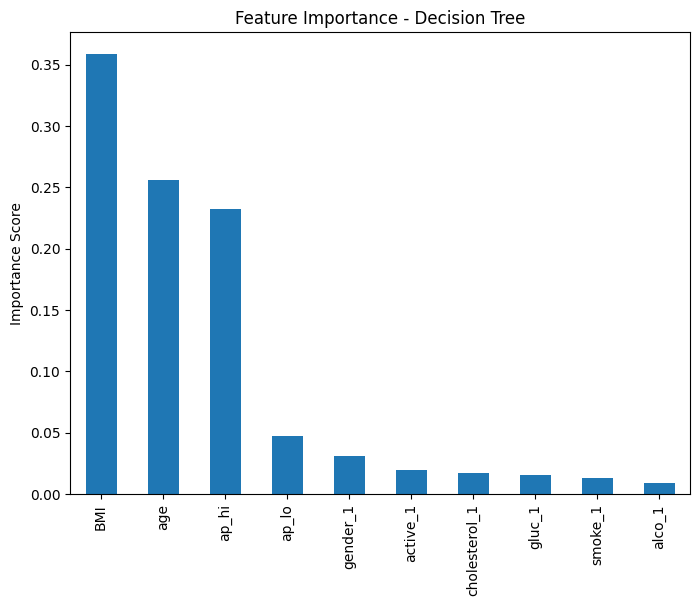

In [ ]:
# Get feature importance scores from the trained model
importances = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 6))
importances.plot(kind='bar')
plt.title('Feature Importance - Decision Tree')
plt.ylabel('Importance Score')
plt.show()

**6.2.3 Predict class probabilities**

In [ ]:
# Predict the class probabilities
y_train_dt_proba = dt.predict_proba(X_train)[:, 1]

**6.2.4 Predict with default 0.5 cutoff**

In [ ]:
# Make prediction based on default cutoff value of 0.5
y_train_dt_pred = (y_train_dt_proba >= 0.5).astype(int)

**6.2.5 Evaluate on training data**

In [ ]:
# Evaluate the performance of the model on training data
print(classification_report(y_train, y_train_dt_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24279
           1       0.99      1.00      1.00     23772

    accuracy                           1.00     48051
   macro avg       1.00      1.00      1.00     48051
weighted avg       1.00      1.00      1.00     48051



**6.2.6 ROC Curve**

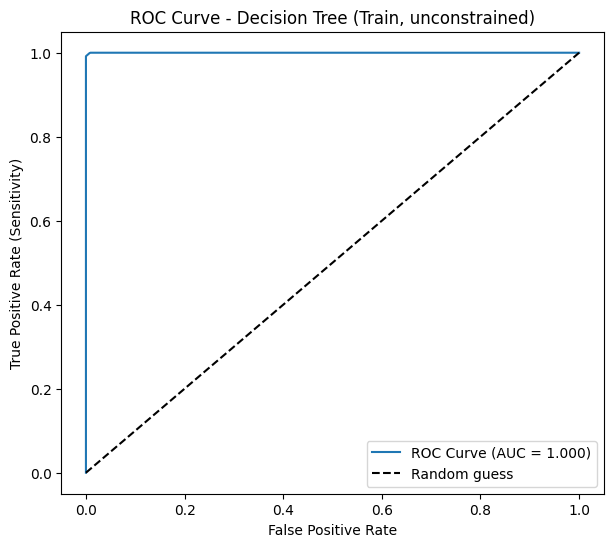

In [ ]:
# Plot the ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_train, y_train_dt_proba)
auc_dt = roc_auc_score(y_train, y_train_dt_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_dt, tpr_dt, label=f'ROC Curve (AUC = {auc_dt:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Decision Tree (Train, unconstrained)')
plt.legend()
plt.show()

**6.2.7 Sensitivity/specificity/accuracy tradeoff**

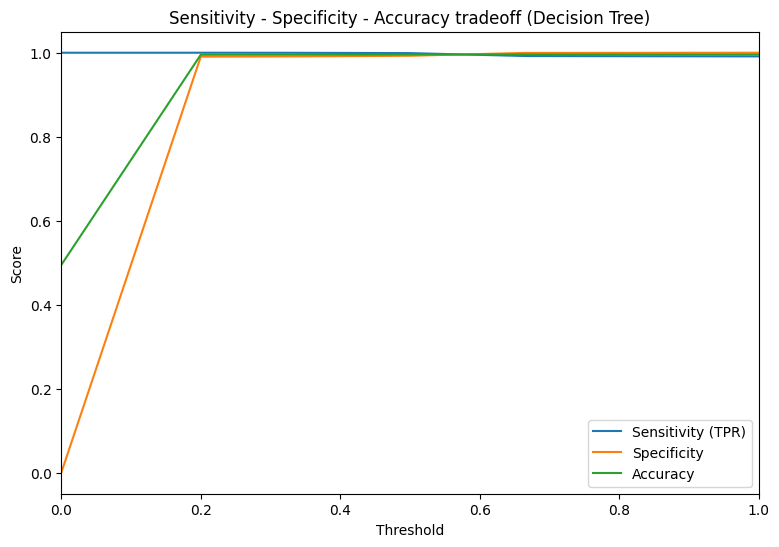

In [ ]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df_dt = pd.DataFrame({'threshold': thresholds_dt, 'tpr': tpr_dt, 'fpr': fpr_dt})
cutoff_df_dt['specificity'] = 1 - cutoff_df_dt['fpr']

accuracies_dt = []
for t in thresholds_dt:
    preds = (y_train_dt_proba >= t).astype(int)
    accuracies_dt.append(accuracy_score(y_train, preds))
cutoff_df_dt['accuracy'] = accuracies_dt

# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
plt.figure(figsize=(9, 6))
plt.plot(cutoff_df_dt['threshold'], cutoff_df_dt['tpr'], label='Sensitivity (TPR)')
plt.plot(cutoff_df_dt['threshold'], cutoff_df_dt['specificity'], label='Specificity')
plt.plot(cutoff_df_dt['threshold'], cutoff_df_dt['accuracy'], label='Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Sensitivity - Specificity - Accuracy tradeoff (Decision Tree)')
plt.legend()
plt.xlim(0, 1)
plt.show()

**6.2.8 Final predictions on train AND test with chosen cutoff**

In [ ]:
# Make final prediction based on the optimal cutoff (0.5, since curve gives no clear crossover pre-tuning)
optimal_cutoff_dt = 0.5

y_train_dt_final = (y_train_dt_proba >= optimal_cutoff_dt).astype(int)

y_test_dt_proba = dt.predict_proba(X_test)[:, 1]
y_test_dt_final = (y_test_dt_proba >= optimal_cutoff_dt).astype(int)

print("Train performance:")
print(classification_report(y_train, y_train_dt_final))
print("\nTest performance:")
print(classification_report(y_test, y_test_dt_final))

Train performance:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24279
           1       0.99      1.00      1.00     23772

    accuracy                           1.00     48051
   macro avg       1.00      1.00      1.00     48051
weighted avg       1.00      1.00      1.00     48051


Test performance:
              precision    recall  f1-score   support

           0       0.64      0.63      0.64     10405
           1       0.63      0.63      0.63     10189

    accuracy                           0.63     20594
   macro avg       0.63      0.63      0.63     20594
weighted avg       0.63      0.63      0.63     20594



**6.2.9 Precision-Recall curve**

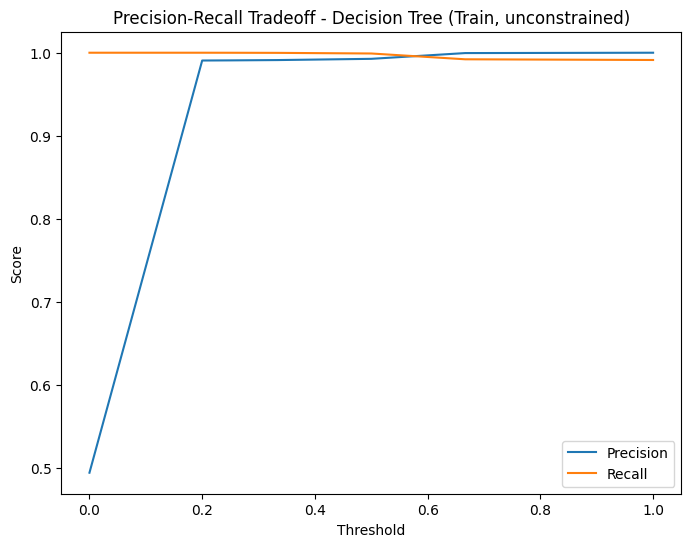

In [ ]:
# Compute and plot precision–recall values
precision_dt, recall_dt, pr_thresholds_dt = precision_recall_curve(y_train, y_train_dt_proba)

plt.figure(figsize=(8, 6))
plt.plot(pr_thresholds_dt, precision_dt[:-1], label='Precision')
plt.plot(pr_thresholds_dt, recall_dt[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff - Decision Tree (Train, unconstrained)')
plt.legend()
plt.show()

# 6.3 Hyperparameter Tuning

**6.3.1 Grid Search for Decision Tree**

In [ ]:
# Use grid search to find best hyperparameters for decision tree model

# Define the parameter grid for the decision tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

# Print the best hyperparameters
print("Best parameters:", dt_grid.best_params_)
print("Best CV AUC score:", dt_grid.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 50}
Best CV AUC score: 0.7901827856436359


**6.3.2 Build final Decision Tree using best hyperparameters**

In [ ]:
# Use the best DT from grid search
best_dt = dt_grid.best_estimator_
best_dt.fit(X_train, y_train)

# Get probabilities and predictions on train and test
y_train_bestdt_proba = best_dt.predict_proba(X_train)[:, 1]
y_test_bestdt_proba = best_dt.predict_proba(X_test)[:, 1]

y_train_bestdt_pred = (y_train_bestdt_proba >= 0.5).astype(int)
y_test_bestdt_pred = (y_test_bestdt_proba >= 0.5).astype(int)

print("Train performance (tuned DT):")
print(classification_report(y_train, y_train_bestdt_pred))
print("\nTest performance (tuned DT):")
print(classification_report(y_test, y_test_bestdt_pred))

Train performance (tuned DT):
              precision    recall  f1-score   support

           0       0.72      0.76      0.74     24279
           1       0.74      0.70      0.72     23772

    accuracy                           0.73     48051
   macro avg       0.73      0.73      0.73     48051
weighted avg       0.73      0.73      0.73     48051


Test performance (tuned DT):
              precision    recall  f1-score   support

           0       0.72      0.75      0.73     10405
           1       0.73      0.70      0.72     10189

    accuracy                           0.73     20594
   macro avg       0.73      0.73      0.73     20594
weighted avg       0.73      0.73      0.73     20594



**6.3.4 SVM Grid Search**

In [ ]:
# Grid search for SVM hyperparameters (kernel, C, gamma)
param_grid_svm = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1]
}

svm_grid = GridSearchCV(
    SVC(probability=False, random_state=42),
    param_grid_svm,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best parameters:", svm_grid.best_params_)
print("Best CV AUC score:", svm_grid.best_score_)

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV AUC score: 0.787870564152438


In [ ]:
# Build final SVM using best hyperparameters from grid search, with probability=True this time
best_svm = SVC(kernel='rbf', C=10, gamma=0.1, probability=True, random_state=42)
best_svm.fit(X_train, y_train)

y_train_bestsvm_proba = best_svm.predict_proba(X_train)[:, 1]
y_test_bestsvm_proba = best_svm.predict_proba(X_test)[:, 1]

y_train_bestsvm_pred = (y_train_bestsvm_proba >= 0.5).astype(int)
y_test_bestsvm_pred = (y_test_bestsvm_proba >= 0.5).astype(int)

print("Train performance (tuned RBF SVM):")
print(classification_report(y_train, y_train_bestsvm_pred))
print("\nTest performance (tuned RBF SVM):")
print(classification_report(y_test, y_test_bestsvm_pred))

Train performance (tuned RBF SVM):
              precision    recall  f1-score   support

           0       0.72      0.74      0.73     24279
           1       0.73      0.71      0.72     23772

    accuracy                           0.72     48051
   macro avg       0.72      0.72      0.72     48051
weighted avg       0.72      0.72      0.72     48051


Test performance (tuned RBF SVM):
              precision    recall  f1-score   support

           0       0.72      0.74      0.73     10405
           1       0.73      0.71      0.72     10189

    accuracy                           0.72     20594
   macro avg       0.72      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594



# **Section 7: Final Model Evaluation and Selection**

**7.1 Evaluate the final Models**

**7.1.1 Make final predictions and evaluate**

In [ ]:
# Make predictions on test and train sets using all candidate models, using each model's chosen optimal cutoff

results = []

# Linear SVM (original, optimal cutoff = 0.4412)
results.append(['Linear SVM', 'Train', accuracy_score(y_train, (y_train_pred_proba >= optimal_cutoff).astype(int)),
                 roc_auc_score(y_train, y_train_pred_proba)])
results.append(['Linear SVM', 'Test', accuracy_score(y_test, (y_test_pred_proba >= optimal_cutoff).astype(int)),
                 roc_auc_score(y_test, y_test_pred_proba)])

# Tuned Decision Tree (cutoff = 0.5)
results.append(['Tuned Decision Tree', 'Train', accuracy_score(y_train, y_train_bestdt_pred),
                 roc_auc_score(y_train, y_train_bestdt_proba)])
results.append(['Tuned Decision Tree', 'Test', accuracy_score(y_test, y_test_bestdt_pred),
                 roc_auc_score(y_test, y_test_bestdt_proba)])

# Tuned RBF SVM (cutoff = 0.5)
results.append(['Tuned RBF SVM', 'Train', accuracy_score(y_train, y_train_bestsvm_pred),
                 roc_auc_score(y_train, y_train_bestsvm_proba)])
results.append(['Tuned RBF SVM', 'Test', accuracy_score(y_test, y_test_bestsvm_pred),
                 roc_auc_score(y_test, y_test_bestsvm_proba)])

results_df = pd.DataFrame(results, columns=['Model', 'Dataset', 'Accuracy', 'AUC'])
results_df

,Model,Dataset,Accuracy,AUC
0,Linear SVM,Train,0.724459,0.787862
1,Linear SVM,Test,0.725260,0.790209
2,Tuned Decision Tree,Train,0.733117,0.800163
3,Tuned Decision Tree,Test,0.726037,0.793845
4,Tuned RBF SVM,Train,0.724168,0.789519
5,Tuned RBF SVM,Test,0.724434,0.790282


**7.2.1 Model Cards**

# Model Card 1: Linear SVM

**Model Card: Linear SVM (Cardiovascular Risk Classifier)**

**Model overview:**
A linear Support Vector Machine trained to classify patients as at-risk (1) or not at-risk (0)
for cardiovascular disease based on demographic, physiological, and lifestyle features.

**Intended use:**
- Primary task: Binary classification (cardio risk screening)
- Intended users: Healthcare providers for early-stage patient risk triage
- Suitable setting: Initial screening tool to prioritize patients for further clinical consultation —
  not a replacement for diagnostic testing
**Data and features:**
- Raw features: age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active
- Engineered: BMI (from height + weight); cholesterol and gluc categories combined (1&2 → 1) to reduce sparsity
- Dropped: height, weight, height_m (redundant after BMI creation, 0.85 correlation with BMI)
- Preprocessing: MinMax scaling on age/ap_hi/ap_lo/BMI; one-hot encoding on categorical features

**Model configuration:**
- Algorithm: SVC, linear kernel, probability=True
- Key hyperparameters: default C (baseline model)
- Optimal cutoff: 0.4412 (chosen via sensitivity-specificity crossover)

**Performance:**
- Train: Accuracy 72%, AUC 0.788
- Test: Accuracy 73%, AUC ~0.79 (minimal train-test gap — good generalization)

**Limitations:**
- Linear decision boundary may miss complex non-linear interactions between features
- predict() and predict_proba() showed 2.72% disagreement due to SVC's internal probability calibration

# Model Card 2: Tuned Decision Tree

**Model Card: Tuned Decision Tree (Cardiovascular Risk Classifier)**

**Model overview:**
A Decision Tree classifier, hyperparameter-tuned via grid search, predicting cardiovascular
disease risk with an emphasis on interpretability.

**Intended use:**
- Primary task: Binary classification (cardio risk screening)
- Intended users: Healthcare providers wanting an interpretable model with clear decision rules
- Suitable setting: Screening tool where explainability of individual predictions matters (e.g.,
  showing a clinician which factors drove a specific patient's risk flag)

**Data and features:**
- Same feature set as Linear SVM (BMI-engineered, categories combined, scaled, dummy-encoded)
- Feature importance revealed BMI (0.36), age (0.26), and ap_hi (0.23) as dominant predictors,
  together accounting for ~85% of the tree's splits
**Model configuration:**
- Algorithm: DecisionTreeClassifier
- Tuned hyperparameters (via GridSearchCV, 5-fold CV, scoring=roc_auc):
  criterion='gini', max_depth=7, min_samples_leaf=10, min_samples_split=50
- Cutoff: 0.5

**Performance:**
- Unconstrained baseline: Train 100% / Test 63% (severe overfitting, 37-point gap)
- Tuned model: Train 73% / Test 73% (gap closed to <1 point)
- Best CV AUC: 0.790

**Limitations:**
- Slightly less smooth probability estimates than SVM
- Performance ceiling similar to linear SVM, suggesting limited additional signal from non-linear splits

# Model Card 3: Tuned RBF SVM

### Model Card: Tuned RBF SVM (Cardiovascular Risk Classifier)

**Model overview:**
A Support Vector Machine using the RBF (non-linear) kernel, hyperparameter-tuned via grid search,
predicting cardiovascular disease risk by capturing potentially non-linear feature interactions.

**Intended use:**
- Primary task: Binary classification (cardio risk screening)
- Intended users: Healthcare providers for early-stage patient risk triage
- Suitable setting: Screening tool where potential non-linear feature interactions might matter,
  though findings below suggest this added complexity was not necessary for this dataset

**Data and features:**
- Same feature set as other models (BMI-engineered, categories combined, scaled, dummy-encoded)
**Model configuration:**
- Algorithm: SVC, RBF kernel
- Tuned hyperparameters (via GridSearchCV, 3-fold CV, scoring=roc_auc): C=10, gamma=0.1
- Best CV AUC: 0.788
- Cutoff: 0.5

**Performance:**
- Train: Accuracy 72%, minimal gap to test — no overfitting
- Test: Accuracy 72%
- Performance is nearly identical to the baseline Linear SVM (72-73% test) and tuned Decision Tree (73% test)

**Limitations:**
- Higher computational cost than Linear SVM or Decision Tree, with no corresponding performance gain
- The RBF kernel's added flexibility did not translate into better discrimination, suggesting the
  true relationship in this data is largely linear — this model's added complexity is not justified
  in practice

**7.2.2 Conclusions and Outcomes**

**1. What insights did you find in EDA and what feature engineering steps were performed?**

EDA revealed that blood pressure (ap_hi, ap_lo) and age showed the clearest separation between
cardio-positive and cardio-negative patients, while height showed almost none. Among categorical
features, cholesterol showed the strongest gradient (cardio rate rising from 43.5% to 76.3% across
categories), followed by glucose. Interestingly, smoking and alcohol consumption showed weak,
counter-intuitive (slightly negative) relationships with cardio risk — likely confounded by other
factors rather than truly protective. ap_hi and ap_lo were found to be moderately correlated (0.73),
consistent with physiological expectations.

For feature engineering, we: (1) converted age from days to years and added height in meters for
interpretability, (2) engineered BMI from height and weight, then dropped the original height/weight
columns after finding BMI was highly correlated with weight (0.85) to reduce redundancy, (3) combined
sparse cholesterol and glucose categories (1 and 2) into a single "abnormal" flag to reduce sparsity,
(4) created dummy variables for all categorical features, and (5) applied MinMax scaling to numerical
features to support distance-sensitive models like SVM.

**2. Did you find overfitting? How was it handled and what was the result of tuning?**

Yes — the unconstrained Decision Tree showed severe overfitting, achieving 100% training accuracy
but only 63% test accuracy (a 37-point gap), indicating the model had memorized training data rather
than learning generalizable patterns. This was addressed via GridSearchCV, tuning max_depth,
min_samples_split, min_samples_leaf, and criterion. The tuned tree (max_depth=7, min_samples_leaf=10,
min_samples_split=50, criterion='gini') achieved near-identical train and test accuracy (73% both),
completely eliminating the overfitting gap while also improving test performance. The Linear SVM, by
contrast, showed no meaningful overfitting even in its baseline form (72% train vs 73% test), likely
due to its simpler, more constrained linear decision boundary.

**3. Was the data sufficient?**

Yes, the dataset (68,645 cleaned records after removing ~1,355 invalid physiological entries) was
large and balanced (50.5%/49.5% class split), which allowed reliable model training and evaluation
without needing techniques like SMOTE or class weighting. However, some features (smoking, alcohol)
showed weak or counter-intuitive relationships with the target, suggesting the dataset may be missing
other relevant clinical factors (e.g., family history, diet, existing conditions) that could improve
predictive power further.

**4. Is linear model sufficient?**

Largely, yes. The tuned RBF SVM (non-linear kernel) achieved a CV AUC of ~0.788, essentially identical
to the original Linear SVM's AUC of 0.788 — the more flexible non-linear kernel provided no meaningful
improvement. This suggests the relationship between the given features and cardiovascular risk is
largely linear/additive in nature, and a simpler linear model is sufficient, offering the added benefits
of faster training and easier interpretability without sacrificing performance.

**5. What model did you choose and why?**

Given that all three tuned models (Linear SVM, Tuned Decision Tree, Tuned RBF SVM) achieved nearly
identical test performance (72.4-72.6% accuracy, 0.79-0.794 AUC), the choice comes down to secondary
criteria beyond raw accuracy. We recommend the Tuned Decision Tree as the final model, for three reasons:
(1) it achieved the marginally highest test accuracy (72.6%) and test AUC (0.794) of the three, (2) it
offers direct interpretability via feature importances (BMI, age, and ap_hi accounted for ~85% of split
decisions), which is valuable for clinicians who need to understand why a patient was flagged as at-risk,
and (3) it is far faster to train and score than either SVM variant, an operational advantage for
real-world deployment at scale. The RBF SVM, despite its added non-linear flexibility and higher
computational cost, provided no measurable benefit over the simpler Linear SVM, reinforcing that a
non-linear model was not necessary for this problem.

**6. What were the final outcomes in the modelling process?**

The final modelling process successfully produced a cardiovascular risk classifier achieving ~73%
accuracy and ~0.79 AUC on unseen test data, using a compact, interpretable feature set derived through
BMI engineering and category consolidation. Critically, the initial severe overfitting observed in the
baseline Decision Tree (100% train vs. 63% test accuracy) was fully resolved through hyperparameter
tuning, bringing the model to a well-generalized 73%/73% train-test split. The near-identical performance
across linear and non-linear models confirms that the relationship between the given physiological and
lifestyle features and cardiovascular risk is largely linear, and that a simpler, faster, and more
interpretable model can be deployed without sacrificing predictive performance — supporting the business
goal of a fast, reliable initial screening tool for prioritizing patient consultations.